<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Line Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on using line charts to analyze trends over time and across different categories in a dataset.



## Objectives


In this lab you will perform the following:


- Track trends in compensation across age groups and specific age ranges.

- Analyze job satisfaction trends based on experience level.

- Explore and interpret line charts to identify patterns and trends.


## Setup: Working with the Database
**Install the needed libraries**


In [ ]:
!pip install pandas


In [ ]:
!pip install matplotlib

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



#### Step 1: Download the dataset


In [ ]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv


#### Step 2: Import necessary libraries and load the dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

#### Load the data


In [2]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


#### Display the first few rows to understand the structure of the data


In [3]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Trends in Compensation Over Age Groups


##### 1. Line Chart of Median `ConvertedCompYearly` by Age Group


- Track how the median yearly compensation (ConvertedCompYearly) changes across different age groups.

- Use a line chart to visualize these trends.


,Respondents,MedianCompensation
Age,,
Under 18 years old,64,7626.5
18-24 years old,3433,25000.0
25-34 years old,10369,59825.0
35-44 years old,6231,84796.0
45-54 years old,2329,99099.0
55-64 years old,863,109691.0
65 years or older,137,106000.0


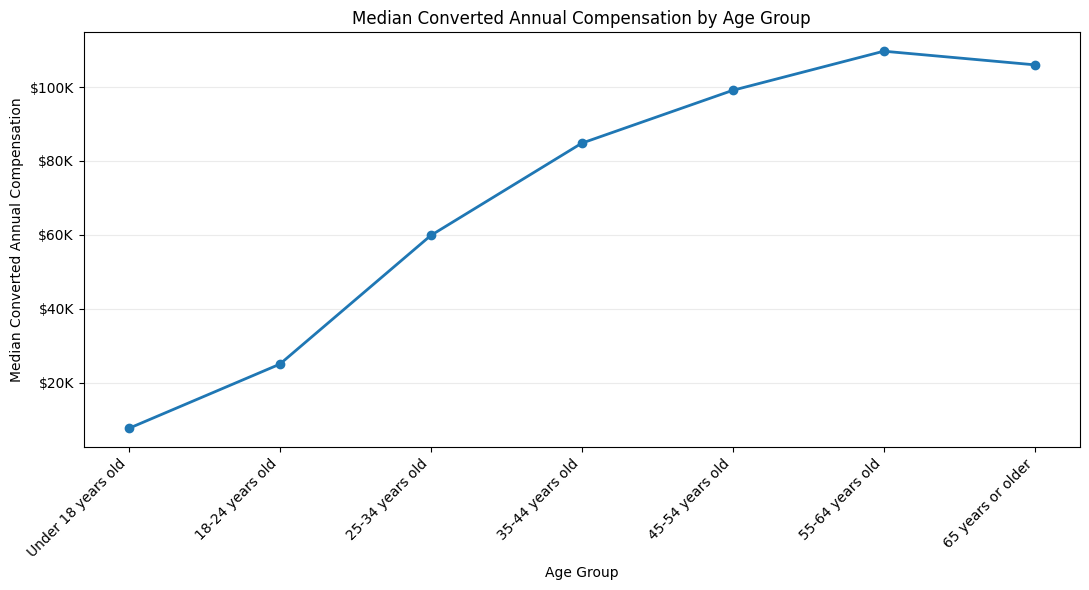

In [5]:
# Task 1.1 - Median ConvertedCompYearly by Age Group

age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

age_comp = df[
    ["Age", "ConvertedCompYearly"]
].copy()

age_comp["ConvertedCompYearly"] = pd.to_numeric(
    age_comp["ConvertedCompYearly"],
    errors="coerce"
)

age_comp = age_comp[
    age_comp["Age"].isin(age_order)
]

age_comp_summary = (
    age_comp
    .groupby("Age")["ConvertedCompYearly"]
    .agg(
        Respondents="count",
        MedianCompensation="median"
    )
    .reindex(age_order)
    .dropna(subset=["MedianCompensation"])
)

display(age_comp_summary.round(2))

x = np.arange(len(age_comp_summary))

plt.figure(figsize=(11, 6))

plt.plot(
    x,
    age_comp_summary["MedianCompensation"],
    marker="o",
    linewidth=2
)

plt.xticks(
    x,
    age_comp_summary.index,
    rotation=45,
    ha="right"
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, pos:
        f"${value/1_000_000:.1f}M"
        if abs(value) >= 1_000_000
        else f"${value/1_000:.0f}K"
    )
)

plt.title("Median Converted Annual Compensation by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Median Converted Annual Compensation")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


#### Analysis

The line chart tracks the **median converted annual compensation** across the survey's age groups. Median compensation is used instead of the mean because compensation data is strongly right-skewed and contains extreme values; the median therefore provides a more stable representation of typical earnings.

The chart should be read as a career-stage trend rather than a continuous age curve, because `Age` is recorded in broad categories. An upward profile across early and middle age groups would be consistent with compensation increasing as respondents accumulate experience and move into more senior roles. Any flattening or decline in the oldest group should be interpreted cautiously because that group contains fewer observations and may represent a different mix of employment situations.

Earlier exploratory analysis of this dataset showed a moderate positive association between age and converted compensation, while also demonstrating substantial variation. Age is therefore relevant to compensation, but it is not sufficient to explain earnings on its own; role, country, industry, seniority, and work experience remain important factors.


##### 2. Line Chart of Median `ConvertedCompYearly` for Ages 25 to 45


For a closer look, plot a line chart focusing on the median compensation for respondents between ages 25 and 45.


In [ ]:
# Task 1.2 - Median ConvertedCompYearly for Ages 25 to 45

# Exact ages are not available. The two complete age groups inside the
# requested interval are 25-34 and 35-44.
focus_age_groups = [
    "25-34 years old",
    "35-44 years old"
]

focus_comp = df[
    ["Age", "ConvertedCompYearly"]
].copy()

focus_comp["ConvertedCompYearly"] = pd.to_numeric(
    focus_comp["ConvertedCompYearly"],
    errors="coerce"
)

focus_comp = focus_comp[
    focus_comp["Age"].isin(focus_age_groups)
]

focus_summary = (
    focus_comp
    .groupby("Age")["ConvertedCompYearly"]
    .agg(
        Respondents="count",
        MedianCompensation="median"
    )
    .reindex(focus_age_groups)
)

display(focus_summary.round(2))

x = np.arange(len(focus_summary))

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    focus_summary["MedianCompensation"],
    marker="o",
    linewidth=2
)

plt.xticks(x, focus_summary.index)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, pos:
        f"${value/1_000_000:.1f}M"
        if abs(value) >= 1_000_000
        else f"${value/1_000:.0f}K"
    )
)

plt.title("Median Converted Annual Compensation for Ages 25-44")
plt.xlabel("Available Age Group")
plt.ylabel("Median Converted Annual Compensation")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


#### Analysis

The dataset does not contain exact ages, so the requested range of 25-45 cannot be isolated precisely. The analysis uses `25-34 years old` and `35-44 years old`, which are the two complete survey categories contained within the requested interval. Age 45 belongs to the broader `45-54` category and cannot be included without also introducing respondents older than the requested range.

The line therefore provides a focused comparison of typical compensation between early-career/mid-career age bands. A higher median in the 35-44 group would be consistent with the broader pattern that compensation tends to increase with accumulated experience and seniority. However, the result should still be interpreted as an age-group association rather than evidence that age itself causes higher compensation.


### Task 2: Trends in Job Satisfaction by Experience Level



##### 1. Line Chart of Job Satisfaction (`JobSatPoints_6`) by Experience Level



- Use a column that approximates experience level to analyze how job satisfaction changes with experience.

- If needed, substitute an available experience-related column for `Experience`.


In [ ]:
# Task 2.1 - Job Satisfaction by Experience Level

experience_sat = df[
    ["WorkExp", "JobSatPoints_6"]
].copy()

experience_sat["WorkExp"] = pd.to_numeric(
    experience_sat["WorkExp"],
    errors="coerce"
)
experience_sat["JobSatPoints_6"] = pd.to_numeric(
    experience_sat["JobSatPoints_6"],
    errors="coerce"
)

experience_sat = experience_sat.dropna(
    subset=["WorkExp", "JobSatPoints_6"]
)

experience_sat = experience_sat[
    experience_sat["WorkExp"] >= 0
]

# Convert years of work experience into interpretable career stages.
bins = [-0.01, 5, 10, 20, 30, np.inf]
labels = [
    "0-5 years",
    "6-10 years",
    "11-20 years",
    "21-30 years",
    "31+ years"
]

experience_sat["ExperienceLevel"] = pd.cut(
    experience_sat["WorkExp"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

experience_summary = (
    experience_sat
    .groupby(
        "ExperienceLevel",
        observed=True
    )["JobSatPoints_6"]
    .agg(
        Respondents="count",
        MedianJobSatPoints6="median"
    )
    .reindex(labels)
)

display(experience_summary.round(2))

x = np.arange(len(experience_summary))

plt.figure(figsize=(9, 5))

plt.plot(
    x,
    experience_summary["MedianJobSatPoints6"],
    marker="o",
    linewidth=2
)

plt.xticks(x, experience_summary.index)
plt.title("Median Job Satisfaction Component by Experience Level")
plt.xlabel("Work Experience Level")
plt.ylabel("Median JobSatPoints_6")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


#### Analysis

This chart summarizes `JobSatPoints_6` across broad work-experience stages rather than individual years. Grouping experience into career stages reduces noise and makes long-term patterns easier to interpret.

Previous correlation analysis in this dataset showed only a weak relationship between work experience and this job-satisfaction component. Therefore, large monotonic increases or decreases are not expected. Similar median values across the experience groups would reinforce the conclusion that professional experience alone has limited explanatory power for job satisfaction.

Any differences between career stages should be treated as descriptive. Satisfaction can also be affected by compensation, workload, role, management, work arrangement, career progression, and other factors that are not isolated in this chart.


### Task 3: Trends in Job Satisfaction and Compensation by Experience


##### 1.Line Chart of Median ConvertedCompYearly Over Experience Level

- This line chart will track how median compensation (`ConvertedCompYearly`) changes with increasing experience.

- Use a column such as `WorkExp` or another relevant experience-related column.


In [ ]:
# Task 3.1 - Median ConvertedCompYearly Over Work Experience

experience_comp = df[
    ["WorkExp", "ConvertedCompYearly"]
].copy()

experience_comp["WorkExp"] = pd.to_numeric(
    experience_comp["WorkExp"],
    errors="coerce"
)
experience_comp["ConvertedCompYearly"] = pd.to_numeric(
    experience_comp["ConvertedCompYearly"],
    errors="coerce"
)

experience_comp = experience_comp.dropna(
    subset=["WorkExp", "ConvertedCompYearly"]
)

experience_comp = experience_comp[
    experience_comp["WorkExp"] >= 0
]

experience_comp_summary = (
    experience_comp
    .groupby("WorkExp")["ConvertedCompYearly"]
    .agg(
        Respondents="count",
        MedianCompensation="median"
    )
    .sort_index()
)

display(experience_comp_summary.round(2))

plt.figure(figsize=(11, 6))

plt.plot(
    experience_comp_summary.index,
    experience_comp_summary["MedianCompensation"],
    marker="o",
    linewidth=1.8
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, pos:
        f"${value/1_000_000:.1f}M"
        if abs(value) >= 1_000_000
        else f"${value/1_000:.0f}K"
    )
)

plt.title("Median Converted Annual Compensation by Work Experience")
plt.xlabel("Years of Work Experience")
plt.ylabel("Median Converted Annual Compensation")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


#### Analysis

The line chart tracks median converted annual compensation across individual years of work experience. Using the median limits the impact of exceptionally high compensation values and makes the underlying career progression easier to see.

Earlier analysis of the same dataset showed a moderate positive association between `WorkExp` and `ConvertedCompYearly` (approximately 0.41). The line chart provides a more interpretable view of that relationship: compensation generally tends to rise as professional experience accumulates, but the progression is not expected to be perfectly linear.

Fluctuations at very high experience levels should be interpreted cautiously because those groups typically contain fewer respondents and can therefore produce less stable medians. Experience is an important compensation factor, but differences in occupation, country, seniority, industry, and employment arrangement also contribute to salary variation.


##### 2.Line Chart of Job Satisfaction (`JobSatPoints_6`) Across Experience Levels

- Create a line chart to explore trends in job satisfaction (`JobSatPoints_6`) based on experience level.

- This chart will provide insight into how satisfaction correlates with experience over time


In [ ]:
# Task 3.2 - JobSatPoints_6 Across Work Experience Levels

experience_sat_year = df[
    ["WorkExp", "JobSatPoints_6"]
].copy()

experience_sat_year["WorkExp"] = pd.to_numeric(
    experience_sat_year["WorkExp"],
    errors="coerce"
)
experience_sat_year["JobSatPoints_6"] = pd.to_numeric(
    experience_sat_year["JobSatPoints_6"],
    errors="coerce"
)

experience_sat_year = experience_sat_year.dropna(
    subset=["WorkExp", "JobSatPoints_6"]
)

experience_sat_year = experience_sat_year[
    experience_sat_year["WorkExp"] >= 0
]

experience_sat_year_summary = (
    experience_sat_year
    .groupby("WorkExp")["JobSatPoints_6"]
    .agg(
        Respondents="count",
        MedianJobSatPoints6="median"
    )
    .sort_index()
)

display(experience_sat_year_summary.round(2))

plt.figure(figsize=(11, 6))

plt.plot(
    experience_sat_year_summary.index,
    experience_sat_year_summary["MedianJobSatPoints6"],
    marker="o",
    linewidth=1.8
)

plt.title("Median Job Satisfaction Component by Years of Work Experience")
plt.xlabel("Years of Work Experience")
plt.ylabel("Median JobSatPoints_6")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


#### Analysis

This line chart provides a more granular view of `JobSatPoints_6` by plotting the median value for each reported year of work experience. Unlike the broader career-stage view in Task 2, this chart makes local fluctuations visible.

The expected pattern is substantially weaker than the compensation trend. Previous exploratory results showed that the linear relationship between work experience and this job-satisfaction component is close to zero. Accordingly, the line may fluctuate across experience levels without forming a sustained upward or downward trajectory.

This result supports the interpretation that job satisfaction is multidimensional and cannot be explained by tenure or experience alone. Values at the far end of the experience range may also be more volatile because fewer respondents are represented there. The chart describes association and variation, not causation.


#### Final Step: Review


In this lab, you focused on analyzing trends in compensation and job satisfaction, specifically exploring how these metrics change with age and experience levels using line charts.


### Summary


In this lab, you explored essential data visualization techniques with a focus on analyzing trends using line charts. You learned to:

- Visualize the distribution of compensation across age groups to understand salary trends.

- Track changes in median compensation over various experience levels, identifying how earnings progress with experience.

- Examine trends in job satisfaction by experience, revealing how satisfaction varies throughout a developer's career.

These analyses allow for a deeper understanding of how factors like age and experience influence job satisfaction and compensation. By using line charts, you gained insights into continuous data patterns, which are invaluable for interpreting professional trends in the developer community.
